# Delamanid resistance: stable causal graph (corrected orientation)

> **What the graphs show.** No single mutation stands out as a reliable direct input to the delamanid MIC (none clears the 0.5 bar). The closest candidates are `pepq_Ala87Gly` and the efflux-cluster variants (`rv1979c_C*135G`, `rv0678_G*128C`, `mmpl5_*`). Lineage and resistance type do not survive as inputs. What that means is left to the reader.

**Question.** Which mutations are picked as direct inputs to the delamanid MIC, once lineage, resistance type, and the other mutations are all accounted for?

See [README.md](README.md) for how to read these graphs, the reliability number, the node colours, and the modelling choices (continuous MIC, lineage and type placed downstream, stability selection).

**Lineage arrows (complete-structure view only).** an arrow from a mutation into a lineage just means the mutation and that lineage tend to occur together; nothing ever points from lineage into a mutation.

In [1]:
import sys, warnings; from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parents[2]))
from src.causal_discovery.cmm_utils import show_graph, parents_of
LINFIX = 'tb_subsampling_dlm_mp4_k6_mcc4_linfix'

## Inputs to the delamanid MIC (adjusting for lineage)

Focused view: only the edges pointing into `dlm_mic`.

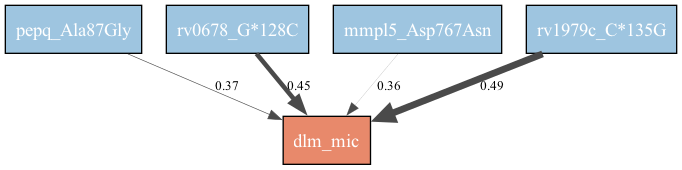

In [2]:
show_graph(f'{LINFIX}/with_lineage', ['dlm_mic'])

In [3]:
parents_of(f'{LINFIX}/with_lineage', 'dlm_mic')

,source,frequency
0,rv1979c_C*135G,0.49
1,rv0678_G*128C,0.45
2,pepq_Ala87Gly,0.37
3,mmpl5_Asp767Asn,0.36
4,mmpl5_Thr794Ile,0.18
5,fgd1_Phe320Phe,0.17
6,lineage_4,0.15
7,fgd1_G*357C,0.14
8,lineage_2,0.10
9,mmpl5_Ile948Val,0.10


## Same model, complete structure

Adds the mutation-mutation and mutation -> lineage co-occurrence edges (background), for completeness. Note nothing points from lineage into a mutation.

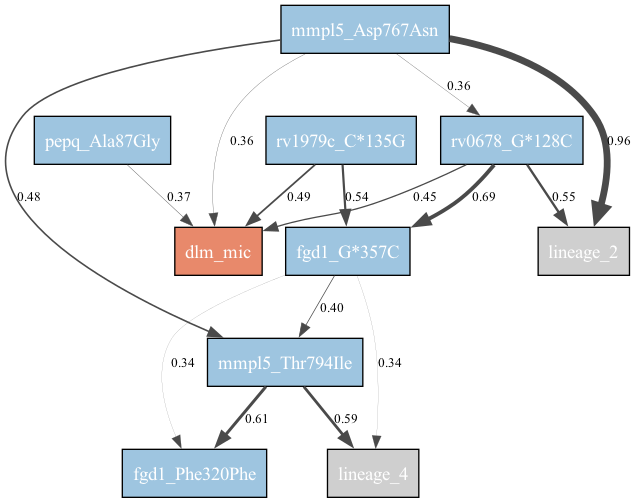

In [4]:
show_graph(f'{LINFIX}/with_lineage', ['dlm_mic'], into_only=False)

## Adjusting resistance type out (type treated as downstream)

The type label is defined from resistance to other drugs, so here the edge `type -> dlm_mic` is forbidden. With type adjusted out, the remaining signal falls back onto the mutations.

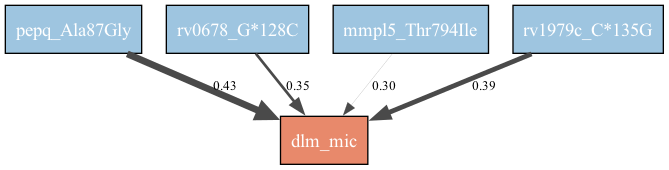

In [5]:
show_graph(f'{LINFIX}/with_lineage_and_type_forbid_type_to_mic', ['dlm_mic'])

In [6]:
parents_of(f'{LINFIX}/with_lineage_and_type_forbid_type_to_mic', 'dlm_mic')

,source,frequency
0,pepq_Ala87Gly,0.43
1,rv1979c_C*135G,0.39
2,rv0678_G*128C,0.35
3,mmpl5_Thr794Ile,0.30
4,mmpl5_Asp767Asn,0.26
5,fgd1_G*357C,0.18
6,fgd1_Phe320Phe,0.18
7,lineage_4,0.10
8,lineage_2,0.10


## What the graph shows

No mutation -> `dlm_mic` edge clears 0.5, so there is no reliable single direct input. The `lineage -> dlm_mic` edge is weak (~0.10). Once resistance type is adjusted out, the remaining signal sits on `pepq_Ala87Gly` (0.43) and the efflux-cluster variants (`rv1979c`, `rv0678`, `mmpl5`), none reaching 0.5; which one leads depends on the adjustment.